# Demo - within-category cosine similarity (notebook 2.2)

Runs the core analysis of **notebook `2.2`** end-to-end on a small **synthetic**
dataset, reproducing every figure 2.2 makes: **single-neuron** and **population**
within-category cosine, the **per-region grid** (ALL / NCM / CMM / Field L), and the
**passive** control.

Each **stimulus is one (strength, interp) pair** -- 4 strengths x 3 interps = 12 stimuli
(keys like `sL_AF_valid_correct_active`). Cosine similarity is compared between the
**same-category** stimuli (same L/R side), matching the manuscript.

Planted effect: during **active** listening, at the **population** scale valid > invalid
(templates more aligned), while at the **single-neuron** scale valid < invalid (single
trials noisier) -- the anticipatory organization is a population-geometry effect. During
**passive** listening there is no difference. Model: the paper's
`cosine ~ validity + (1 + validity | subject) + (1 | population)`.

**Run time:** a few seconds on a normal laptop.

In [1]:
import warnings, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon, ttest_1samp
from make_demo_data import load, BIRD_REGION, STRENGTHS, INTERPS, STIMULI, CATEGORY
warnings.filterwarnings("ignore")

try:
    from edn_popdyn import colors as pal
    VALID_C, INVALID_C = pal.valid, pal.invalid_accent
    COLOR_POS, COLOR_NEG, COLOR_NS = pal.delta_pos, pal.delta_neg, pal.delta_ns
except Exception:
    VALID_C, INVALID_C = "#157b7b", "#B1361E"
    COLOR_POS, COLOR_NEG, COLOR_NS = "#94644e", "#576b30", "#4d4d4e"

SIDE = [CATEGORY[s] for s, ip in STIMULI]     # category (L/R) of each stimulus
SIG_ALPHA = 0.05
td = load("demo_data.npz")
print(f"{len(td)} sessions | {len(STIMULI)} stimuli/session (strength x interp):", STIMULI[:3], "...")

27 sessions | 12 stimuli/session (strength x interp): [('sL', 'AF'), ('sL', 'BF'), ('sL', 'CE')] ...


In [2]:
# ---- region / site mapping (demo: one site per bird, region from BIRD_REGION) ----
def _bird(s):
    m = re.match(r"^(B\d+)", str(s)); return m.group(1) if m else "Unknown"

def add_site_region(df, session_col="session"):
    df = df.copy()
    if "bird" not in df.columns:
        df["bird"] = df[session_col].map(_bird)
    df["region"]  = df["bird"].map(BIRD_REGION).fillna("unknown")
    df["site_id"] = df["bird"]
    return df

def site_filter(df, min_site_sessions=2):
    d = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    ns = d.groupby("site_id")["session"].nunique()
    keep = d[d["site_id"].isin(set(ns[ns >= min_site_sessions].index))].copy()
    keep["delta"] = keep["session_valid_mean"] - keep["session_invalid_mean"]
    return keep

# ---- within-category reduction: average over same-side stimulus pairs (i<j) ----
def _within_category_mean(M):
    n = len(STIMULI); vals = []
    for i in range(n):
        for j in range(i + 1, n):
            if SIDE[i] == SIDE[j] and np.isfinite(M[i, j]):
                vals.append(M[i, j])
    return float(np.mean(vals)) if vals else np.nan

# ---- population cosine: one template per (strength, interp) stimulus ----
def cosine_flat(a, b, eps=1e-12):
    a = np.asarray(a, float).reshape(-1); b = np.asarray(b, float).reshape(-1)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb + eps)) if na >= eps and nb >= eps else np.nan

def template_from_trials(x):
    x = np.asarray(x, float); return np.nanmean(x, 0) if x.ndim == 3 and x.shape[0] >= 1 else None

def group_by_stimulus(td, active_only=True):
    v = {st: [] for st in STIMULI}; iv = {st: [] for st in STIMULI}
    tag = "_active" if active_only else "_passive"
    for key, x in td.items():
        if tag not in key:
            continue
        p = key.split("_"); st = (p[0], p[1])                # (strength, interp)
        val = "valid" if "valid" in p else "invalid" if "invalid" in p else None
        if st in v and val:
            (v if val == "valid" else iv)[st].append(np.asarray(x))
    return v, iv

def cosine_matrix(grp):
    n = len(STIMULI); M = np.full((n, n), np.nan)
    tem = {st: (template_from_trials(grp[st][0]) if grp.get(st) else None) for st in STIMULI}
    for i, a in enumerate(STIMULI):
        for j, b in enumerate(STIMULI):
            if tem[a] is not None and tem[b] is not None:
                M[i, j] = cosine_flat(tem[a], tem[b])
    return M

def analyze_session(td, active_only=True):
    v, iv = group_by_stimulus(td, active_only)
    return _within_category_mean(cosine_matrix(v)), _within_category_mean(cosine_matrix(iv))

In [3]:
# ---- single-neuron: per-unit pairwise trial cosine, same-category stimulus pairs ----
def _acc(k): return "correct" if "_correct_" in k.lower() else "na"
def _val(k): k = k.lower(); return "valid" if "_valid_" in k else "invalid" if "_invalid_" in k else "unk"
def _mok(k, m): return k.lower().endswith("_" + m)

def _pairwise(A, B, u):
    A = np.asarray(A, float); B = np.asarray(B, float)
    XA, XB = A[:, :, u], B[:, :, u]
    na, nb = np.linalg.norm(XA, axis=1), np.linalg.norm(XB, axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        C = (XA @ XB.T) / np.outer(na, nb)
    C = C[np.isfinite(C)]; return float(C.mean()) if C.size else np.nan

def _group_sn(td, modality, accuracy):
    g = {v: {st: [] for st in STIMULI} for v in ("valid", "invalid")}
    for key, arr in td.items():
        if modality and not _mok(key, modality): continue
        if accuracy and _acc(key) != accuracy:  continue
        v = _val(key); p = key.split("_"); st = (p[0], p[1])
        if v in ("valid", "invalid") and st in g[v] and np.asarray(arr).ndim == 3:
            g[v][st].append(np.asarray(arr))
    return g

def _unit_matrix(gstr, u):
    n = len(STIMULI); M = np.full((n, n), np.nan)
    for i, a in enumerate(STIMULI):
        for j, b in enumerate(STIMULI):
            x, y = gstr.get(a, []), gstr.get(b, [])
            if x and y:
                s = _pairwise(x[0], y[0], u)
                if np.isfinite(s): M[i, j] = s
    return M

def compute_unitwise(ntd, modality="active", accuracy="correct"):
    rows = []
    for sess, td in ntd.items():
        g = _group_sn(td, modality, accuracy)
        uc = [np.asarray(A).shape[2] for v in ("valid", "invalid") for st in STIMULI for A in g[v][st]]
        if not uc: continue
        for u in range(min(uc)):
            V = _within_category_mean(_unit_matrix(g["valid"], u))
            I = _within_category_mean(_unit_matrix(g["invalid"], u))
            if np.isfinite(V) and np.isfinite(I):
                rows.append(dict(bird=_bird(sess), session=sess, unit_idx=u, mean_valid=V, mean_invalid=I))
    return pd.DataFrame(rows)

In [4]:
# ---- subject-level LME (same model as 2.2) ----
def _fit(m):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for meth in ("lbfgs", "bfgs", "cg", "powell"):
            try: return m.fit(reml=True, method=meth, maxiter=400)
            except Exception: pass
    return None

def subject_lme(df, label, verbose=True):
    keep = add_site_region(df.dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
    nb = keep["bird"].nunique()
    dd = keep["session_valid_mean"] - keep["session_invalid_mean"]
    bm = keep.assign(delta=dd).groupby("bird")["delta"].mean()
    out = dict(label=label, beta=float(dd.mean()), ci=(np.nan, np.nan), p=np.nan, estimable=False,
               n_birds=nb, n_sessions=keep["session"].nunique(),
               n_pos=int((bm > 0).sum()), n_bird_test=len(bm))
    if nb >= 3:
        long = pd.melt(keep, id_vars=["session", "bird"],
                       value_vars=["session_valid_mean", "session_invalid_mean"],
                       var_name="cr", value_name="value")
        long["condition"] = pd.Categorical(
            long["cr"].map({"session_valid_mean": "Valid", "session_invalid_mean": "Invalid"}),
            categories=["Invalid", "Valid"])
        m = _fit(smf.mixedlm("value ~ condition", long, groups="bird",
                             re_formula="~condition", vc_formula={"session": "0 + C(session)"}))
        if m is not None:
            k = [x for x in m.fe_params.index if x.startswith("condition")][0]
            ci = m.conf_int().loc[k]
            out.update(beta=float(m.fe_params[k]), ci=(float(ci[0]), float(ci[1])),
                       p=float(m.pvalues[k]), estimable=True)
    if verbose:
        if out["estimable"]:
            print("  %-26s b=%+.4f [%+.4f, %+.4f]  P=%.3g  (%d birds, %d pops)"
                  % (label, out["beta"], out["ci"][0], out["ci"][1], out["p"], out["n_birds"], out["n_sessions"]))
        else:
            print("  %-26s n.t. (<3 birds)  b=%+.4f  (%d birds)" % (label, out["beta"], out["n_birds"]))
    return out

In [5]:
# ---- build the session-level tables (active + passive) ----
def _pop_df(active_only):
    return pd.DataFrame([dict(session=s, session_valid_mean=analyze_session(d, active_only)[0],
                              session_invalid_mean=analyze_session(d, active_only)[1])
                         for s, d in td.items()])

def _sn_df(modality, accuracy, keep_sessions):
    du = compute_unitwise(td, modality=modality, accuracy=accuracy)
    dsn = (du.groupby(["bird", "session"])
             .agg(session_valid_mean=("mean_valid", "mean"),
                  session_invalid_mean=("mean_invalid", "mean")).reset_index())
    return add_site_region(dsn[dsn["session"].isin(keep_sessions)]
                           .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())

df_pop_lme  = site_filter(_pop_df(active_only=True))
keep_sess   = set(df_pop_lme["session"])
df_sn_lme   = _sn_df("active", "correct", keep_sess)
df_pop_pass = add_site_region(_pop_df(active_only=False)
                              .dropna(subset=["session_valid_mean", "session_invalid_mean"]).copy())
df_pop_pass = df_pop_pass[df_pop_pass["session"].isin(keep_sess)]
df_sn_pass  = _sn_df("passive", None, keep_sess)
print("active: pop %d pops / %d birds | single-neuron %d pops / %d birds"
      % (df_pop_lme["session"].nunique(), df_pop_lme["bird"].nunique(),
         df_sn_lme["session"].nunique(),  df_sn_lme["bird"].nunique()))

active: pop 27 pops / 9 birds | single-neuron 27 pops / 9 birds


In [6]:
# ---- shared plotting helpers (same as 2.2) ----
OUT_COLS = ("session_valid_mean", "session_invalid_mean")

def _drop_outliers(df, cols=OUT_COLS, k=1.5):
    d = df.dropna(subset=list(cols)).copy(); keep = pd.Series(True, index=d.index)
    for c in cols:
        q1, q3 = d[c].quantile(.25), d[c].quantile(.75); iqr = q3 - q1
        keep &= d[c].between(q1 - k * iqr, q3 + k * iqr)
    return d[keep], int((~keep).sum())

def _sub(df, reg): return df.copy() if reg == "ALL" else df[df["region"] == reg].copy()
def _sig_color(r):
    if r is None or not r.get("estimable") or not np.isfinite(r.get("p", np.nan)) or r["p"] >= SIG_ALPHA:
        return COLOR_NS
    return COLOR_POS if r["beta"] > 0 else COLOR_NEG

def _box(ax, df, title):
    d = df.dropna(subset=list(OUT_COLS))
    if d.empty:
        ax.text(.5, .5, "no data", transform=ax.transAxes, ha="center"); ax.set_title(title, fontsize=9); ax.axis("off"); return
    sv, si = d["session_valid_mean"].values, d["session_invalid_mean"].values
    pdf = pd.DataFrame({"Condition": ["Valid"] * len(sv) + ["Invalid"] * len(si),
                        "Cosine similarity": np.concatenate([sv, si])})
    _n0 = len(ax.collections)
    sns.violinplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                   hue="Condition", palette={"Valid": VALID_C, "Invalid": INVALID_C},
                   inner=None, cut=0, linewidth=0, legend=False, ax=ax)
    for coll in ax.collections[_n0:]:
        coll.set_alpha(0.22); coll.set_edgecolor("none"); coll.set_zorder(0)
    sns.boxplot(data=pdf, x="Condition", y="Cosine similarity", order=["Valid", "Invalid"],
                hue="Condition", palette={"Valid": VALID_C, "Invalid": INVALID_C},
                showfliers=False, width=0.28, legend=False, ax=ax, boxprops=dict(zorder=2))
    ax.set_title(title, fontsize=9); ax.set_xlabel("")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)

ACTIVE - per-region subject LMEs
------------------------------------------------------------------------------
[ALL]
  single-neuron              b=-0.1177 [-0.1567, -0.0787]  P=3.26e-09  (9 birds, 27 pops)
  population                 b=+0.4046 [+0.3399, +0.4693]  P=1.5e-34  (9 birds, 26 pops)


[NCM]
  single-neuron              b=-0.1275 [-0.1751, -0.0798]  P=1.57e-07  (3 birds, 9 pops)
  population                 b=+0.3867 [+0.2804, +0.4930]  P=1.01e-12  (3 birds, 8 pops)
[CMM]
  single-neuron              b=-0.0764 [-0.1367, -0.0162]  P=0.0129  (3 birds, 6 pops)
  population                 b=+0.4244 [+0.2857, +0.5631]  P=2.02e-09  (3 birds, 9 pops)


[Field L]
  single-neuron              b=-0.0961 [-0.1868, -0.0053]  P=0.038  (3 birds, 8 pops)
  population                 b=+0.4332 [+0.3882, +0.4782]  P=2.11e-79  (3 birds, 6 pops)


saved demo_grid_active.png


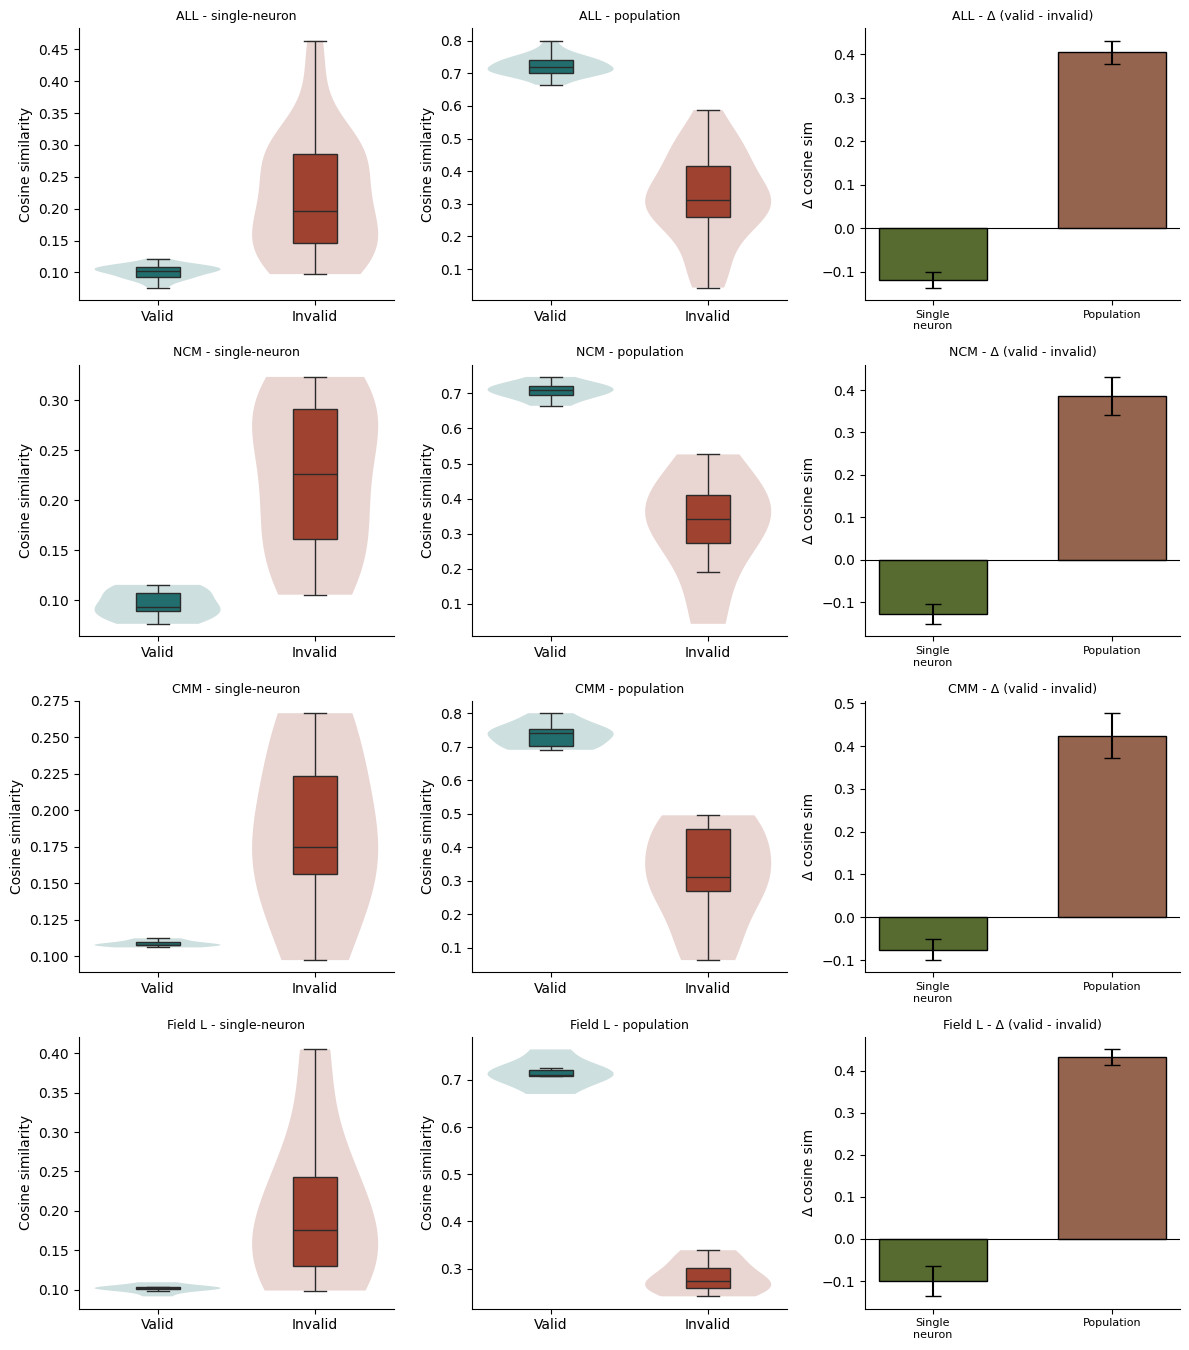

In [7]:
# ==== FIGURE 1: active per-region grid  [single-neuron | population | delta] ====
REGIONS = ["ALL", "NCM", "CMM", "Field L"]
print("=" * 78); print("ACTIVE - per-region subject LMEs"); print("-" * 78)
fig, axes = plt.subplots(len(REGIONS), 3, figsize=(12, 3.4 * len(REGIONS)))
for row, reg in enumerate(REGIONS):
    sdf, _ = _drop_outliers(_sub(df_sn_lme, reg)); pdf, _ = _drop_outliers(_sub(df_pop_lme, reg))
    print(f"[{reg}]")
    rs = subject_lme(sdf, "single-neuron"); rp = subject_lme(pdf, "population")
    ax0, ax1, ax2 = axes[row]
    _box(ax0, sdf, "%s - single-neuron" % reg)
    _box(ax1, pdf, "%s - population"    % reg)
    for xi, (r, d) in enumerate([(rs, sdf), (rp, pdf)]):
        delta = (d["session_valid_mean"] - d["session_invalid_mean"]).dropna()
        if delta.empty: continue
        se = delta.std(ddof=1) / np.sqrt(len(delta)) if len(delta) > 1 else 0.0
        ax2.bar(xi, delta.mean(), yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
    ax2.axhline(0, color="k", lw=.8); ax2.set_xticks([0, 1])
    ax2.set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
    ax2.set_ylabel("Δ cosine sim"); ax2.set_title("%s - Δ (valid - invalid)" % reg, fontsize=9)
    for sp in ("top", "right"): ax2.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig("demo_grid_active.png", dpi=150, bbox_inches="tight")
print("=" * 78, "\nsaved demo_grid_active.png"); plt.show()

PASSIVE - subject LMEs (expected n.s.)
------------------------------------------------------------------------------
  single-neuron (passive)    b=+0.0002 [-0.0434, +0.0437]  P=0.994  (9 birds, 27 pops)
  population (passive)       b=-0.0002 [-0.0479, +0.0474]  P=0.992  (9 birds, 27 pops)


saved demo_passive.png


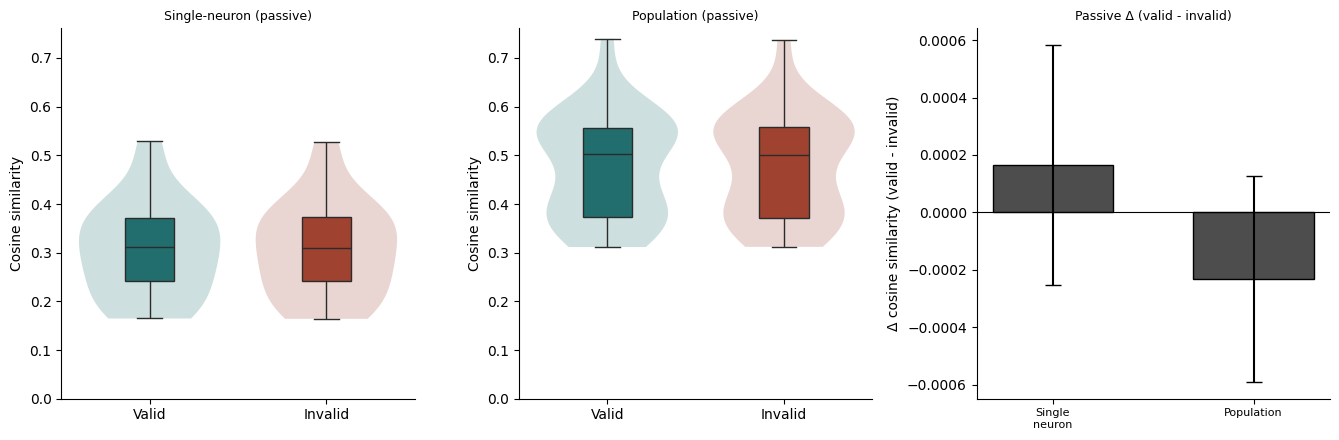

In [8]:
# ==== FIGURE 2: passive control  [single-neuron | population | delta] ====
print("=" * 78); print("PASSIVE - subject LMEs (expected n.s.)"); print("-" * 78)
sn_f, _ = _drop_outliers(df_sn_pass); pop_f, _ = _drop_outliers(df_pop_pass)
res_sn = subject_lme(sn_f, "single-neuron (passive)"); res_pop = subject_lme(pop_f, "population (passive)")
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.5))
_box(ax[0], sn_f,  "Single-neuron (passive)")
_box(ax[1], pop_f, "Population (passive)")
ytop = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1]); ax[0].set_ylim(0, ytop); ax[1].set_ylim(0, ytop)
for xi, (r, d) in enumerate([(res_sn, sn_f), (res_pop, pop_f)]):
    delta = (d["session_valid_mean"] - d["session_invalid_mean"]).dropna()
    if delta.empty: continue
    se = delta.std(ddof=1) / np.sqrt(len(delta)) if len(delta) > 1 else 0.0
    ax[2].bar(xi, delta.mean(), yerr=se, capsize=6, color=_sig_color(r), edgecolor="k", width=0.6)
ax[2].axhline(0, color="k", lw=.8); ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["Single\nneuron", "Population"], fontsize=8)
ax[2].set_ylabel("Δ cosine similarity (valid - invalid)"); ax[2].set_title("Passive Δ (valid - invalid)", fontsize=9)
for sp in ("top", "right"): ax[2].spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig("demo_passive.png", dpi=150, bbox_inches="tight")
print("=" * 78, "\nsaved demo_passive.png"); plt.show()